# Asteroid Near-Earth Object (NEO) Analysis
**Dataset:** NASA NeoWs API — 2,000 Near-Earth Asteroids  
**Target Variable:** `potentially_hazardous` (binary classification)

---


## 1. Imports & Configuration

All libraries are imported here in one place so dependencies are clear at a glance.


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, r2_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print("✅ All imports successful.")


✅ All imports successful.


---
## 2. Load & Inspect the Data


In [61]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


In [62]:
df = pd.read_csv('asteroids_data.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 2,000 rows × 39 columns


,id,neo_id,name,short_name,designation,nasa_url,magnitude,potentially_hazardous,close_approach_data,sentry,...,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion,equinox,orbit_class_type,orbit_class_desc,orbit_class_range,sentry_data
0,2001620,2001620,1620 Geographos (1951 RA),Geographos,1620,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,15.26,True,"[{'close_approach_date': '1901-08-23', 'close_...",False,...,277.018390,1.663750,2.461208e+06,212.920449,0.708833,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN
1,2001863,2001863,1863 Antinous (1948 EA),Antinous,1863,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,15.35,False,"[{'close_approach_date': '1907-10-11', 'close_...",False,...,269.074546,3.630348,2.461243e+06,289.564484,0.290073,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN
2,2001915,2001915,1915 Quetzalcoatl (1953 EA),Quetzalcoatl,1915,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,18.38,False,"[{'close_approach_date': '1906-03-06', 'close_...",False,...,347.755255,3.995972,2.460911e+06,21.616448,0.242780,J2000,AMO,Near-Earth asteroid orbits similar to that of ...,1.017 AU < q (perihelion) < 1.3 AU,NaN
3,2001917,2001917,1917 Cuyo (1968 AA),Cuyo,1917,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,14.38,False,"[{'close_approach_date': '1926-09-28', 'close_...",False,...,194.552572,3.235478,2.460489e+06,160.089498,0.312848,J2000,AMO,Near-Earth asteroid orbits similar to that of ...,1.017 AU < q (perihelion) < 1.3 AU,NaN
4,2002063,2002063,2063 Bacchus (1977 HB),Bacchus,2063,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,17.21,False,"[{'close_approach_date': '1903-03-06', 'close_...",False,...,55.350732,1.454683,2.461143e+06,234.787011,0.880596,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN


In [63]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2000 non-null   int64  
 1   neo_id                    2000 non-null   int64  
 2   name                      2000 non-null   object 
 3   short_name                167 non-null    object 
 4   designation               2000 non-null   int64  
 5   nasa_url                  2000 non-null   object 
 6   magnitude                 2000 non-null   float64
 7   potentially_hazardous     2000 non-null   bool   
 8   close_approach_data       2000 non-null   object 
 9   sentry                    2000 non-null   bool   
 10  api_url                   2000 non-null   object 
 11  diameter_min_m            2000 non-null   float64
 12  diameter_max_m            2000 non-null   float64
 13  orbit_id                  2000 non-null   int64  
 14  orbit_de

In [64]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing.to_string())


Columns with missing values:
sentry_data    1997
short_name     1833


---
## 3. Data Cleaning & Feature Engineering

Steps taken here:
1. Drop columns that are IDs, free-text, or URLs (not useful as model features)
2. Drop near-empty columns (`short_name`, `sentry_data`)
3. Parse date columns and engineer useful time-based features
4. One-hot encode the categorical orbit class column
5. Confirm the final cleaned shape


In [65]:
# Columns to drop: identifiers, raw URLs, redundant text, and near-empty columns
COLS_TO_DROP = [
    'id', 'neo_id', 'name', 'short_name', 'designation',
    'nasa_url', 'api_url',          # identifiers, not directly useful
    'close_approach_data',          # raw JSON string — would need separate parsing
    'sentry_data',                  # almost entirely empty, link to API
    'orbit_class_desc', 'orbit_class_range',  # duplicated by orbit_class_type
    'equinox',                      # constant value (J2000) across all rows
    'epoch',                        # raw date, not directly useful
    'perihelion_time',              # highly correlated with other orbital params
    'sentry',                       # nearly all false except for objects marked hazardous
]

df_clean = df.drop(columns=COLS_TO_DROP)
print(f"Shape after dropping columns: {df_clean.shape}")


Shape after dropping columns: (2000, 24)


In [66]:
# Extract the year of first observation as a feature if the column exists
if 'first_observation_date' in df_clean.columns:
    df_clean['first_obs_year'] = pd.to_datetime(df_clean['first_observation_date']).dt.year
    print("New feature: 'first_obs_year' created.")

# Drop the raw date columns safely using errors='ignore'
date_cols_to_drop = [
    'first_observation_date',
    'last_observation_date',
    'orbit_determination_date'
]
df_clean.drop(columns=date_cols_to_drop, errors='ignore', inplace=True)

print("Date column processing complete.")


New feature: 'first_obs_year' created.
Date column processing complete.


In [67]:
print("Orbit class distribution:")
print(df_clean['orbit_class_type'].value_counts())

# One-hot encode, drop_first avoids the dummy variable trap
df_clean = pd.get_dummies(df_clean, columns=['orbit_class_type'], drop_first=True)

print(f"\nShape after encoding: {df_clean.shape}")
df_clean.head(3)


Orbit class distribution:
orbit_class_type
APO    1022
AMO     808
ATE     165
IEO       5
Name: count, dtype: int64

Shape after encoding: (2000, 24)


,magnitude,potentially_hazardous,diameter_min_m,diameter_max_m,orbit_id,data_arc_days,observations_used,orbit_uncertainty,min_orbit_intersection,jupiter_tisserand,...,orbital_period,perihelion_distance,perihelion_argument,aphelion_distance,mean_anomaly,mean_motion,first_obs_year,orbit_class_type_APO,orbit_class_type_ATE,orbit_class_type_IEO
0,15.26,True,2358.060680,5272.783976,882,27243,9183,0,0.029359,5.074,...,507.877358,0.827804,277.018390,1.663750,212.920449,0.708833,1951,True,False,False
1,15.35,False,2262.324906,5058.712276,305,28532,1804,0,0.187310,3.297,...,1241.064828,0.889883,269.074546,3.630348,289.564484,0.290073,1948,True,False,False
2,18.38,False,560.473362,1253.256538,13,24702,55,0,0.108832,3.122,...,1482.823498,1.093710,347.755255,3.995972,21.616448,0.242780,1953,False,False,False


---
## 4. Exploratory Data Analysis

Steps taken here:
1. Check and group class balance
2. Group non/potentially hazardous by standout features
3. Summarize the data based on key features and compare based on class
4. Graph feature distribution


In [68]:
counts = df_clean['potentially_hazardous'].value_counts()
print(counts)
print(f"\nHazardous rate: {counts[True] / len(df_clean) * 100:.1f}%")

potentially_hazardous
False    1467
True      533
Name: count, dtype: int64

Hazardous rate: 26.7%


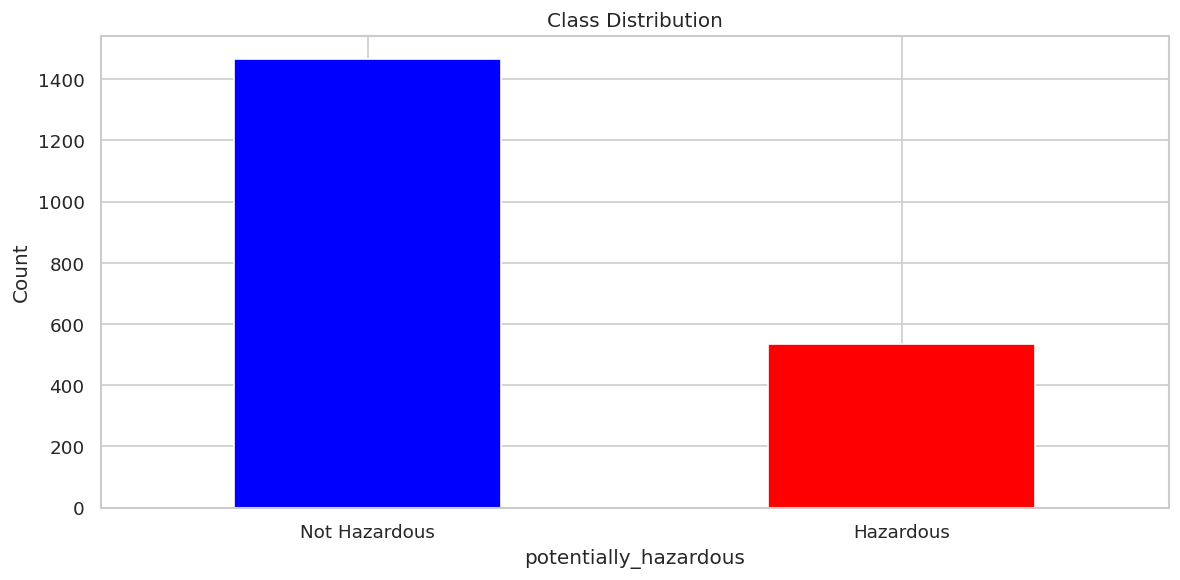

In [69]:
counts.plot(kind='bar', color=['blue', 'red'], edgecolor='white')
plt.xticks([0, 1], ['Not Hazardous', 'Hazardous'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [70]:
KEY_FEATURES = [
    'diameter_min_m', 'diameter_max_m', 'magnitude',
    'inclination', 'orbital_period',
    'perihelion_distance', 'min_orbit_intersection', 'orbit_uncertainty'
]

df_clean.groupby('potentially_hazardous')[KEY_FEATURES].mean().T.round(3)

potentially_hazardous,False,True
diameter_min_m,869.481,614.000
diameter_max_m,1944.219,1372.946
magnitude,18.094,18.778
inclination,19.604,13.511
orbital_period,904.082,737.315
perihelion_distance,0.931,0.752
min_orbit_intersection,0.197,0.022
orbit_uncertainty,0.025,0.028


In [71]:
df_clean.groupby('potentially_hazardous')[KEY_FEATURES].std().T.round(3)

potentially_hazardous,False,True
diameter_min_m,1359.059,543.956
diameter_max_m,3038.948,1216.322
magnitude,1.587,1.553
inclination,13.378,12.568
orbital_period,409.304,357.553
perihelion_distance,0.304,0.221
min_orbit_intersection,0.107,0.014
orbit_uncertainty,0.167,0.166


In [72]:
group_means = df_clean.groupby('potentially_hazardous')[KEY_FEATURES].mean().T
group_means['relative_diff'] = abs(group_means[True] - group_means[False]) / group_means[False] * 100
group_means.sort_values('relative_diff', ascending=False).round(3)


potentially_hazardous,False,True,relative_diff
min_orbit_intersection,0.197,0.022,88.968
inclination,19.604,13.511,31.079
diameter_max_m,1944.219,1372.946,29.383
diameter_min_m,869.481,614.000,29.383
perihelion_distance,0.931,0.752,19.160
orbital_period,904.082,737.315,18.446
orbit_uncertainty,0.025,0.028,14.681
magnitude,18.094,18.778,3.778


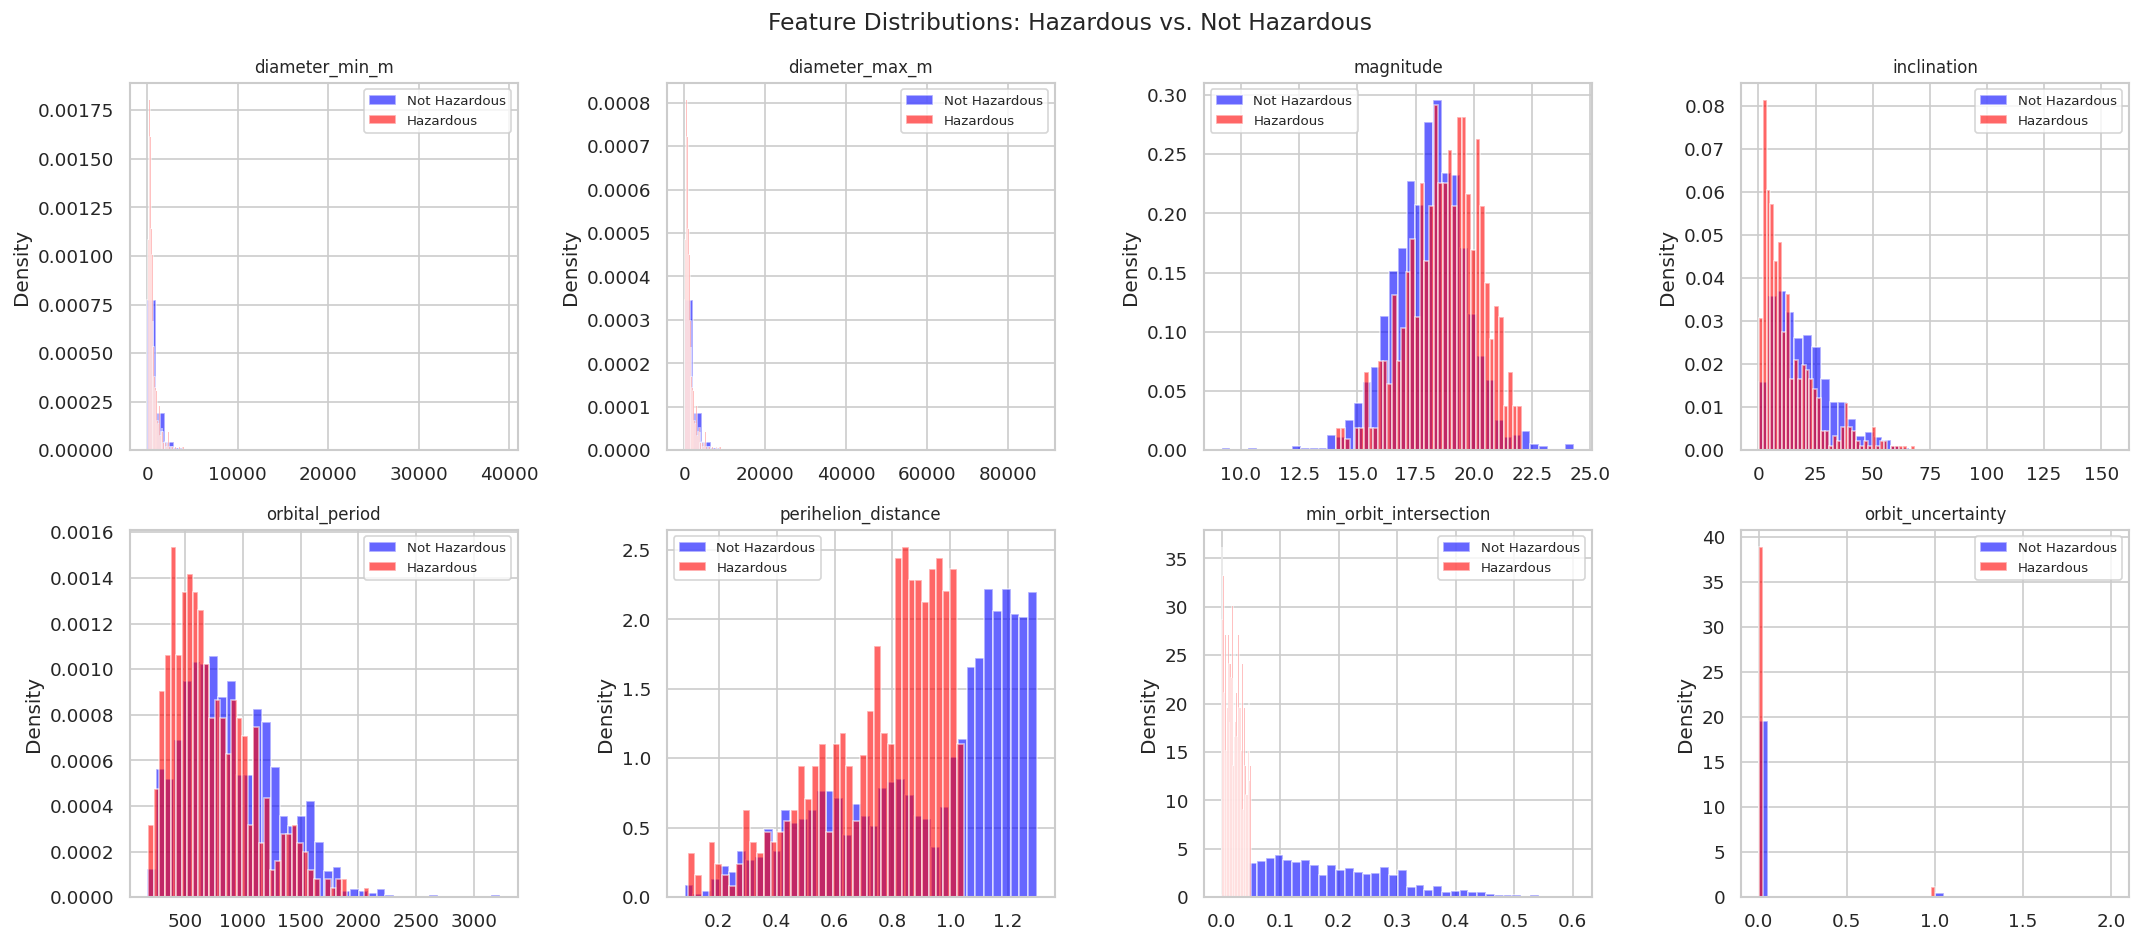

In [73]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    for hazard, color, label in [(False, 'blue', 'Not Hazardous'),
                                  (True, 'red', 'Hazardous')]:
        axes[i].hist(
            df_clean.loc[df_clean['potentially_hazardous'] == hazard, col].dropna(),
            bins=40, alpha=0.6, color=color, label=label, density=True
        )
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Hazardous vs. Not Hazardous', fontsize=14)
plt.tight_layout()
plt.show()

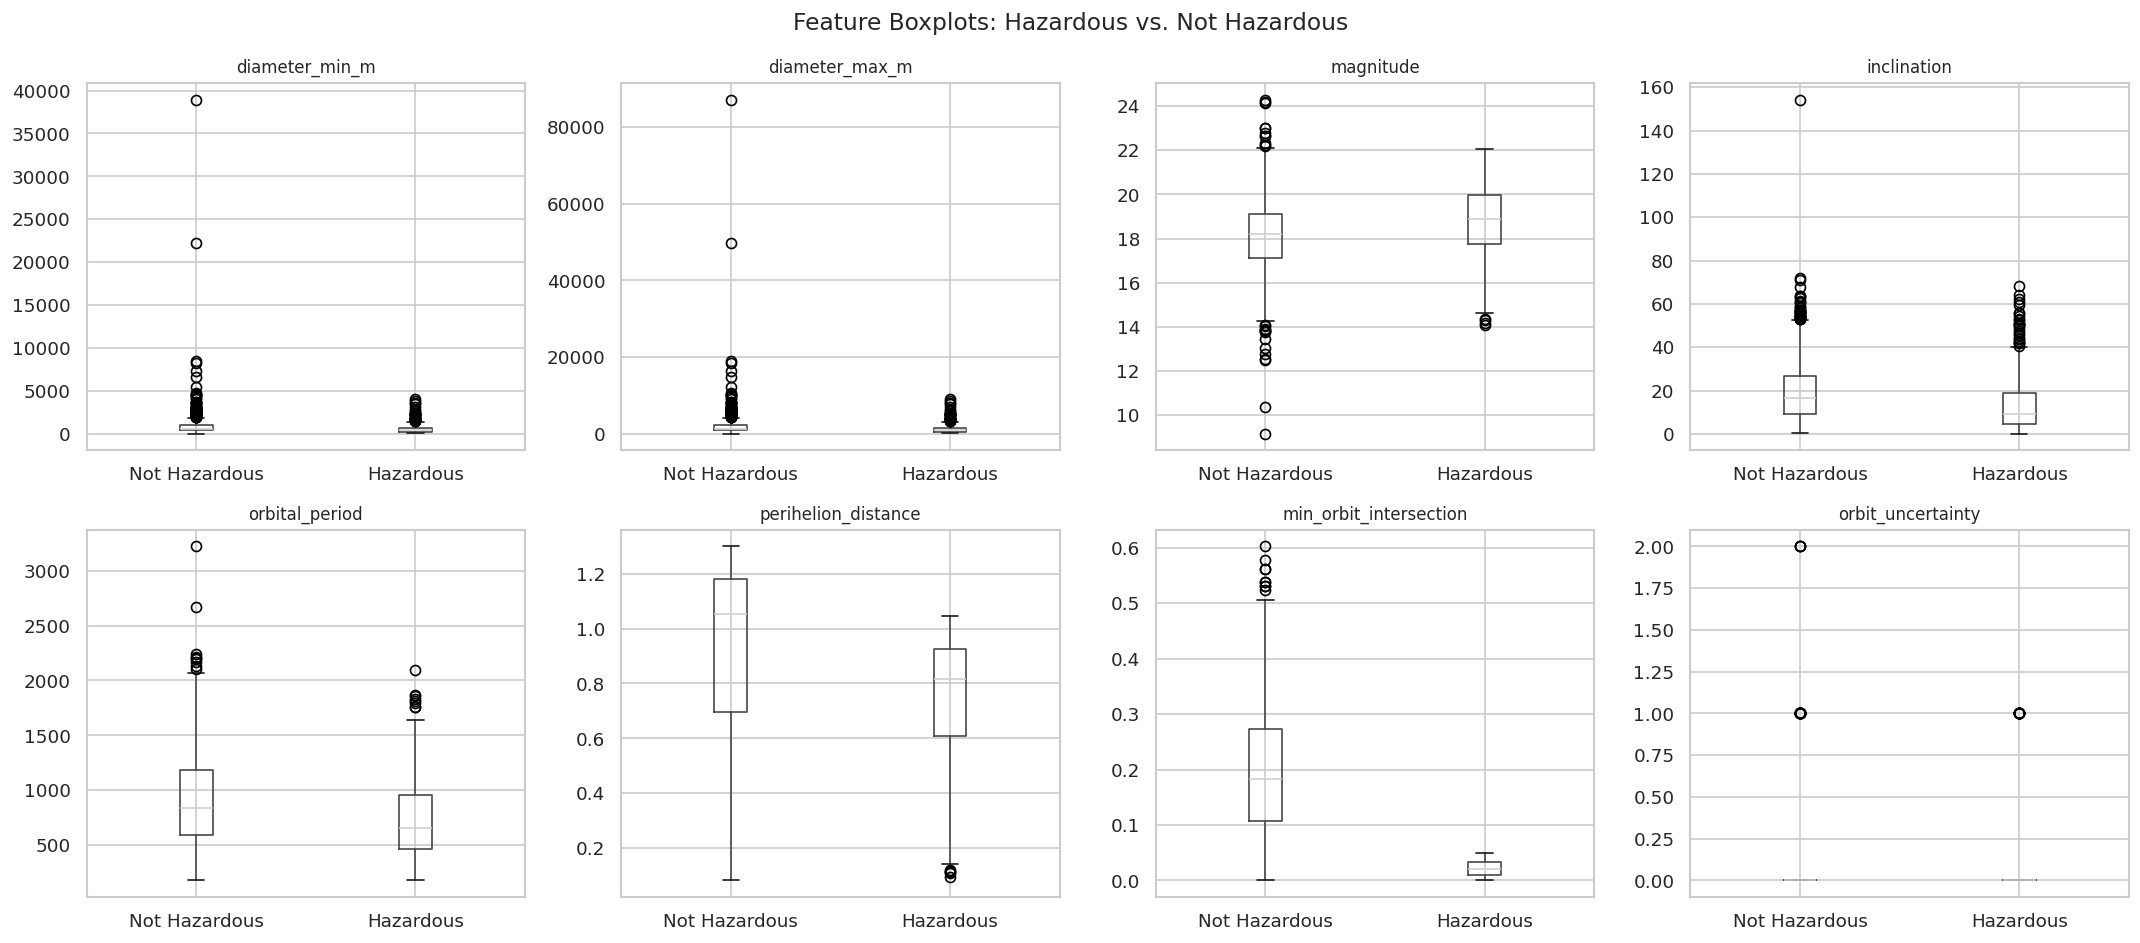

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    df_clean.boxplot(column=col, by='potentially_hazardous', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Not Hazardous', 'Hazardous'])

plt.suptitle('Feature Boxplots: Hazardous vs. Not Hazardous', fontsize=14)
plt.tight_layout()
plt.show()

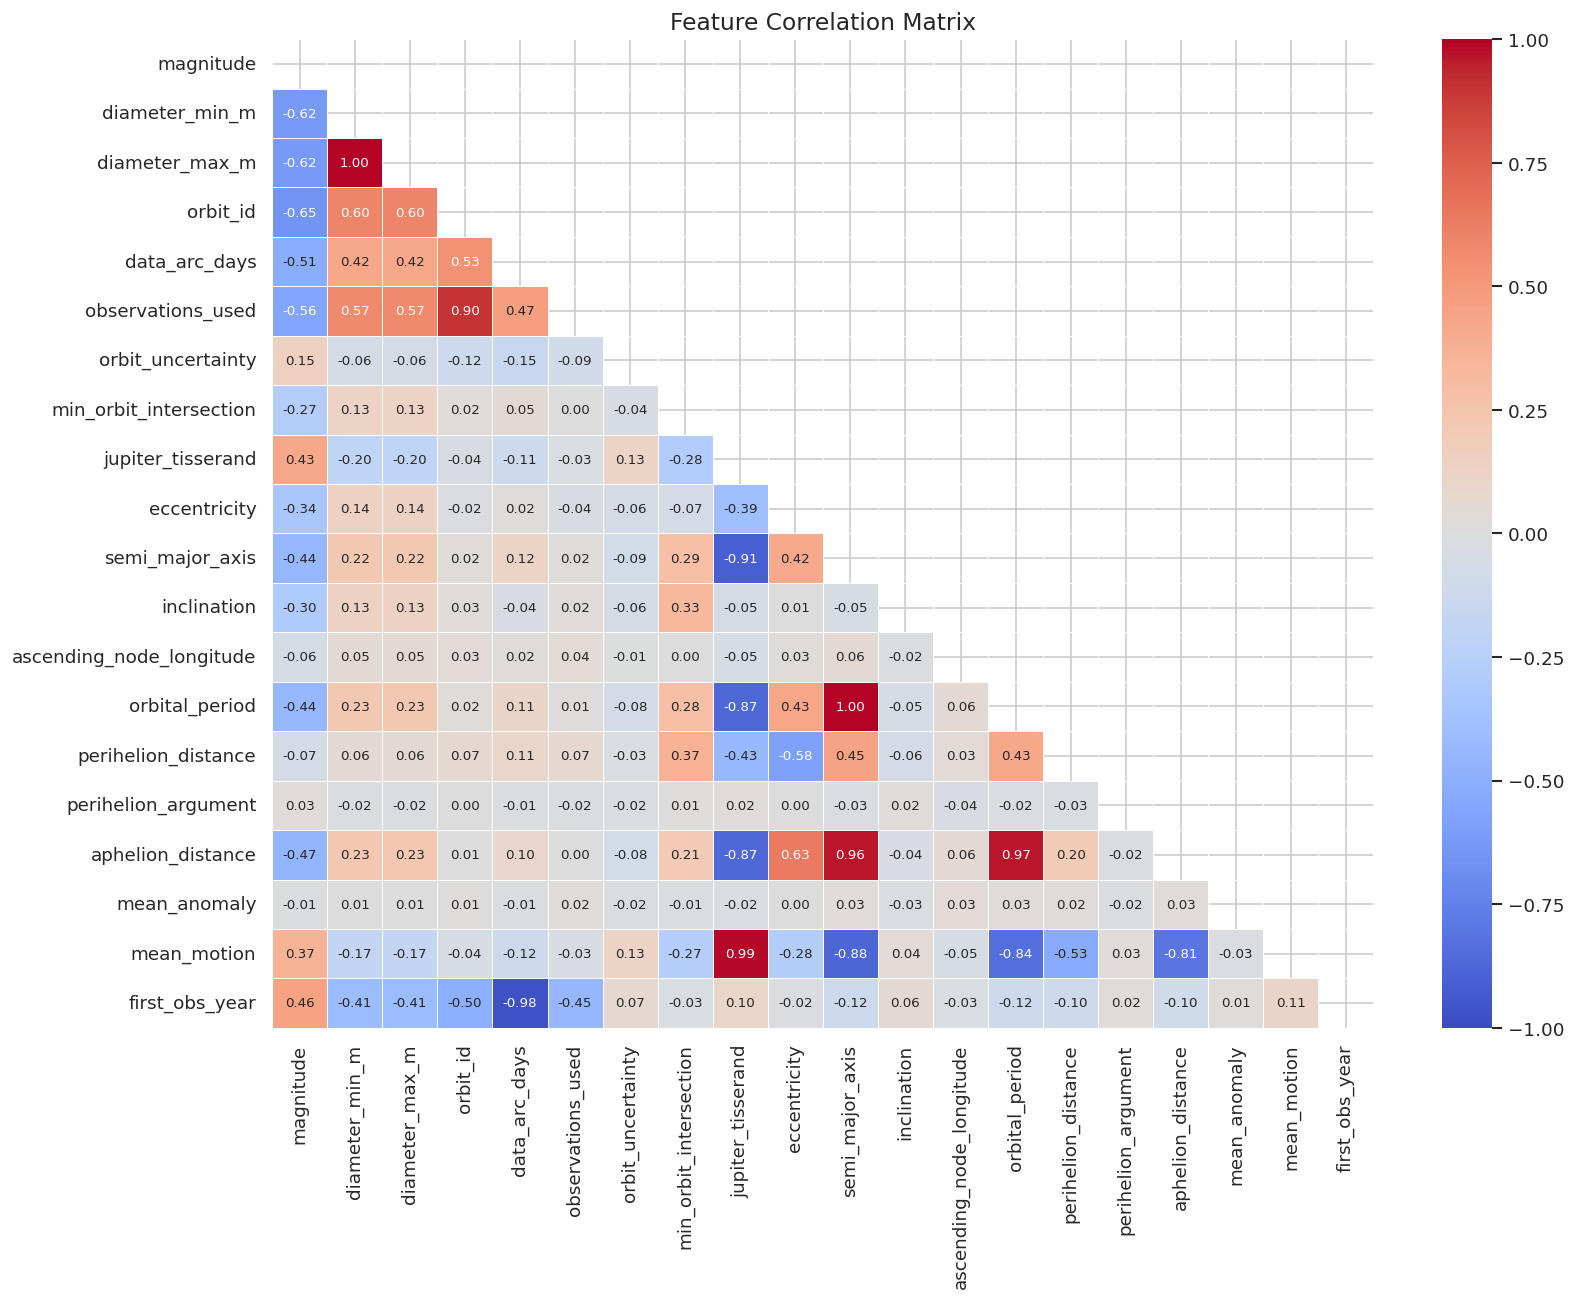

In [75]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

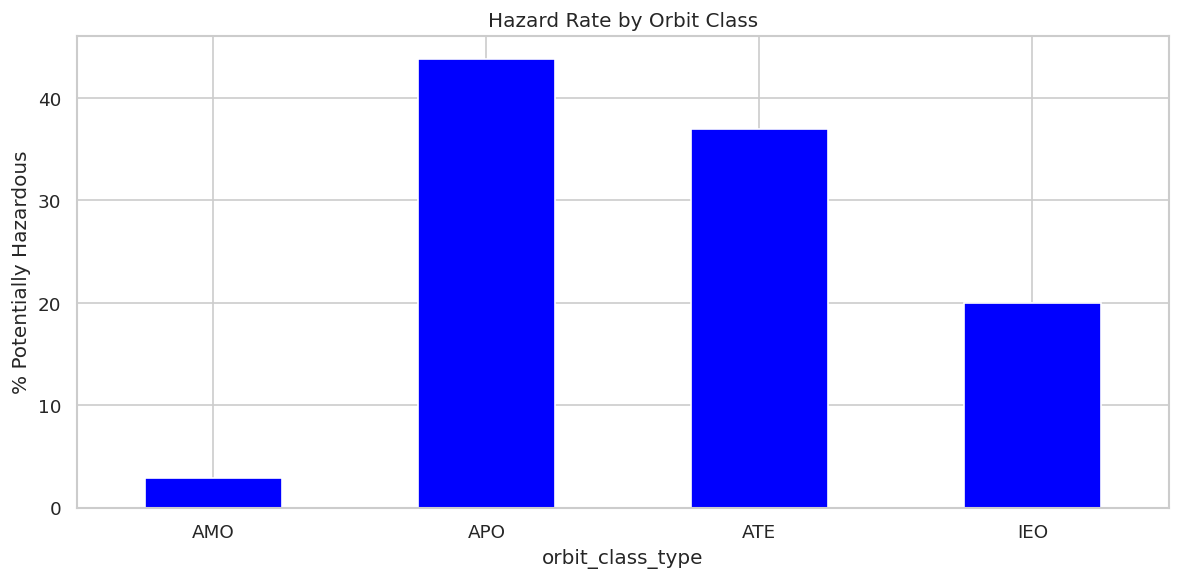

In [76]:
orbit_hazard = df.groupby('orbit_class_type')['potentially_hazardous'].mean() * 100

orbit_hazard.plot(kind='bar', color='blue', edgecolor='white')
plt.ylabel('% Potentially Hazardous')
plt.title('Hazard Rate by Orbit Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


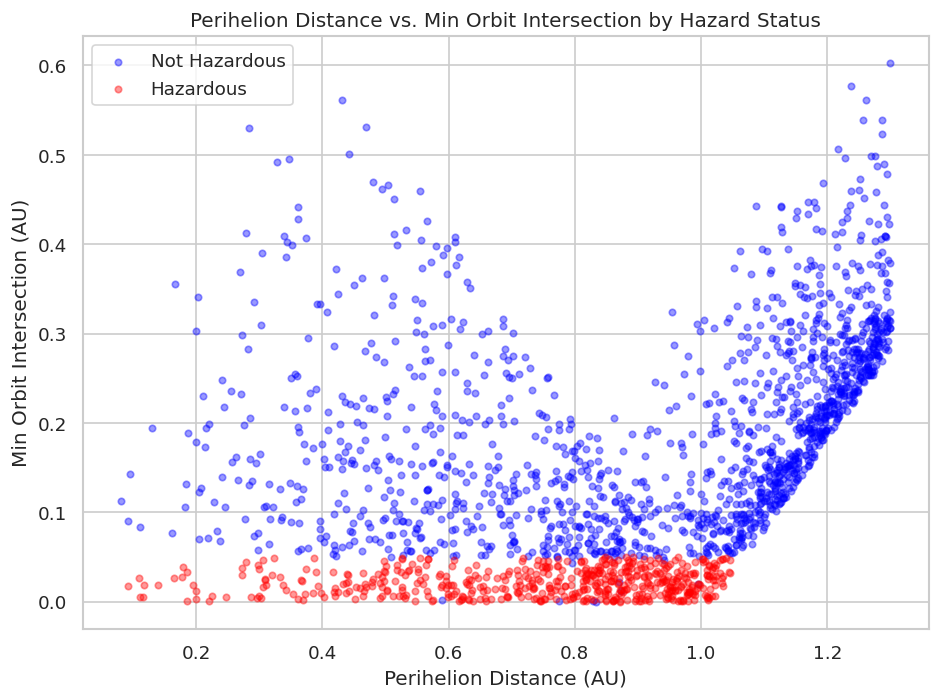

In [77]:
plt.figure(figsize=(8, 6))

for hazard, color, label in [(False, 'blue', 'Not Hazardous'),
                              (True, 'red', 'Hazardous')]:
    subset = df_clean[df_clean['potentially_hazardous'] == hazard]
    plt.scatter(
        subset['perihelion_distance'],
        subset['min_orbit_intersection'],
        alpha=0.4, color=color, label=label, s=15
    )

plt.xlabel('Perihelion Distance (AU)')
plt.ylabel('Min Orbit Intersection (AU)')
plt.title('Perihelion Distance vs. Min Orbit Intersection by Hazard Status')
plt.legend()
plt.tight_layout()
plt.show();

In [78]:
p_above1 = ((df_clean['perihelion_distance'] > 1) & (df_clean['potentially_hazardous'] == True)).sum()
print(f"Number of potentially hazardous objects with perihelion distance > 1 AU: {p_above1}")

Number of potentially hazardous objects with perihelion distance > 1 AU: 44


In [88]:
largest = df_clean.loc[df_clean['diameter_max_m'].idxmax()]

print(f"Largest asteroid by max diameter:")
print(f"  Max Diameter : {largest['diameter_max_m']:,.1f} m  ({largest['diameter_max_m']/1000:.2f} km)")
print(f"  Min Diameter : {largest['diameter_min_m']:,.1f} m  ({largest['diameter_min_m']/1000:.2f} km)")
print(f"  Hazardous    : {largest['potentially_hazardous']}")

Largest asteroid by max diameter:
  Max Diameter : 87,104.4 m  (87.10 km)
  Min Diameter : 38,954.3 m  (38.95 km)
  Hazardous    : False


---
##5. Hypothesis Testing

1. Smaller perihelion distance, min_orbit_intersection, and orbital inclination will all be significantly associated with the potentially hazardous designation.
2. A classification model trained on features like diameter, inclination, orbital period, and minimum orbit intersection distance will achieve perfect recall, since the PHO designation is itself derived from these measurable quantities.


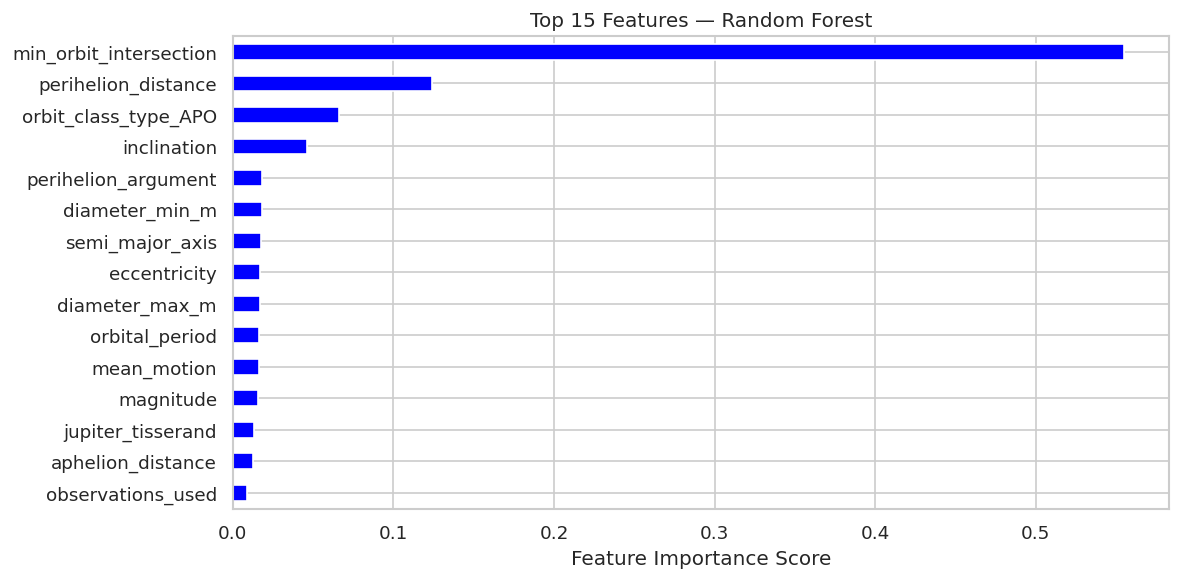

In [79]:
# Hypothesis 1
X = df_clean.drop(columns=['potentially_hazardous'])
y = df_clean['potentially_hazardous'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).sort_values().plot(kind='barh', color='blue')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

The chart above supports the Hypothesis, minimum orbit intersection with Earth and perihelion distance were #1 and #2, and orbital inclination was #4

               precision    recall  f1-score   support

Not Hazardous       1.00      1.00      1.00       293
    Hazardous       1.00      0.99      1.00       107

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400

R² (predicted probability vs actual label): 0.9625


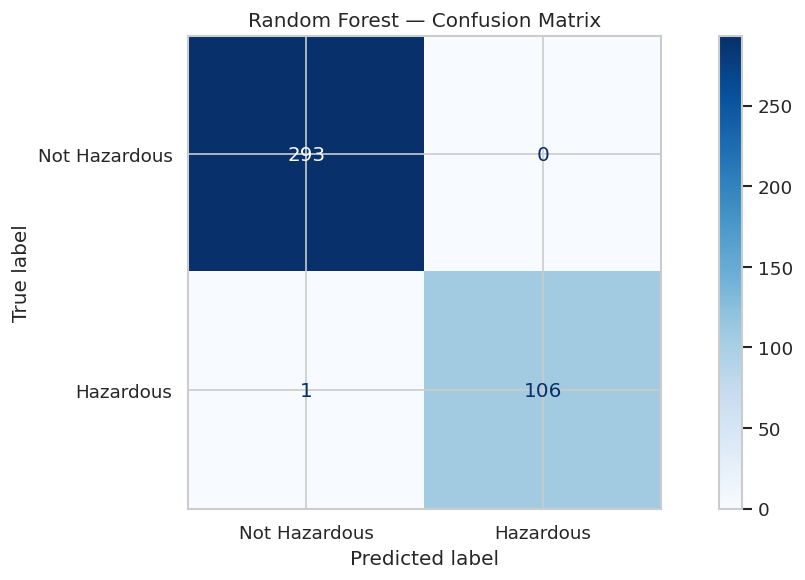

In [85]:
# Hypothesis 2
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]   # predicted probabilities for class 1

# R² of predicted probabilities vs actual binary labels
r2 = r2_score(y_test, y_prob)
print(classification_report(y_test, y_pred, target_names=['Not Hazardous', 'Hazardous']))
print(f"R² (predicted probability vs actual label): {r2:.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not Hazardous', 'Hazardous'], cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()





In [81]:
# Scale data for logistic regression.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

               precision    recall  f1-score   support

Not Hazardous       1.00      0.97      0.98       293
    Hazardous       0.91      1.00      0.96       107

     accuracy                           0.97       400
    macro avg       0.96      0.98      0.97       400
 weighted avg       0.98      0.97      0.98       400

R² (predicted probability vs actual label): 0.9002


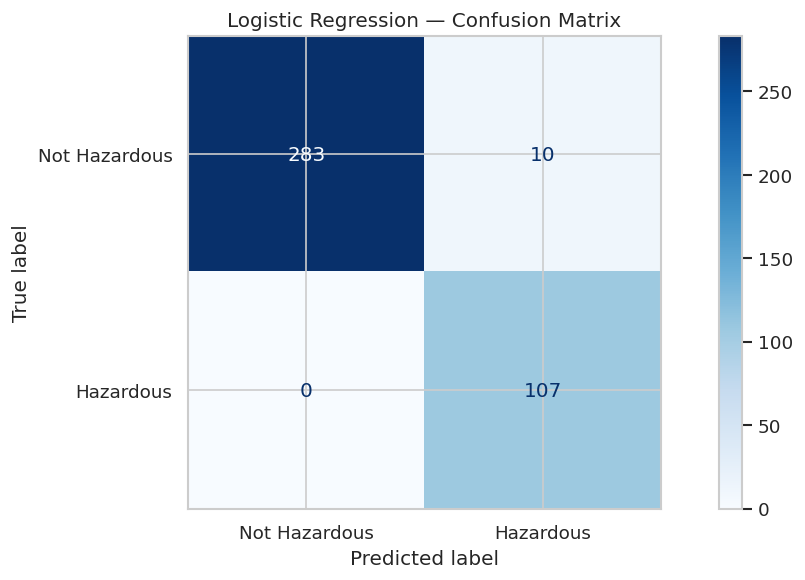

In [87]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Not Hazardous', 'Hazardous']))
print(f"R² (predicted probability vs actual label): {r2_score(y_test, y_prob_lr):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Not Hazardous', 'Hazardous'], cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

The logisitic regression model was able to catch all the hazardous NEOs based only on orbital parameters but will mislabel some non-hazardous NEO's as hazardous. The Random Forrest model, however, will miss at least one hazardous NEO unless the max_depth hyperparameter is limited to <5